# Notebook 2:
### Demand Forecasting by Drug Class

**Purpose**

This notebook generates daily prescription demand forecasts at the drug class level. These forecasts simulate forward-looking workload expectations used for staffing and operational planning.

#### Modeling and feature outputs
- `daily_class_features.csv`
- `daily_demand_by_class.csv`
- `model_metrics_by_class.csv`

#### Forecast outputs
- `predictions_daily_class.csv`
- `forecast_6m_by_class.csv`

#### Operational planning outputs
- `forecast_demand_by_class_day.csv`
- `inventory_suggestions_by_class.csv`

**Key responsibilities**
- Aggregates historical prescription activity
- Produces class-level daily demand forecasts
- Standardizes forecast schema for BI consumption
- Aligns forecast totals with observed prescription volume

In [1]:
# --- Config (paths) ---
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT
OUT_DIR = PROJECT_ROOT / "bi_outputs"
FORECAST_DIR = PROJECT_ROOT / "forecast"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUT_DIR       =", OUT_DIR)
print("FORECAST_DIR  =", FORECAST_DIR)

PROJECT_ROOT = /Users/selenadavis/PythonProject/Notebooks
OUT_DIR       = /Users/selenadavis/PythonProject/Notebooks/bi_outputs
FORECAST_DIR  = /Users/selenadavis/PythonProject/Notebooks/forecast


In [2]:
# --- Imports and configuration ---
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd()
OUT_DIR  = DATA_DIR / "forecast"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def first_existing(*names):
    for n in names:
        p = DATA_DIR / n
        if p.exists():
            return p
    return None

PRESCRIPTIONS_CSV = first_existing("prescriptions.csv", "Prescriptions.csv")
PBC_CSV           = first_existing("prescriptions_by_class.csv", "Prescriptions_by_class.csv")
REF_DRUGS_CSV     = first_existing("ref_drugs.csv", "ref_Drugs.csv", "Ref_drugs.csv", "Ref_Drugs.csv")

HORIZON_DAYS = 180
TEST_DAYS = 90
TOP_N_CLASSES_TO_MODEL = 25
RF_N_ESTIMATORS = 300
RF_RANDOM_STATE = 42

In [3]:
# --- Helpers ---
def _clean_class(x) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def detect_first(df: pd.DataFrame, candidates: list[str], what: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"No {what} column found. Tried: {candidates}. Got columns: {df.columns.tolist()}")

def standardize_prescriptions(rx: pd.DataFrame) -> pd.DataFrame:
    rx = rx.copy()

    date_col = None
    for c in ["RefillDate", "FillDate", "Date"]:
        if c in rx.columns:
            date_col = c
            break
    if date_col is None:
        raise ValueError("prescriptions.csv must include RefillDate or FillDate or Date")

    qty_col = detect_first(rx, ["QuantityDispensed", "Quantity", "Qty", "Units"], "quantity")
    drugid_col = detect_first(rx, ["DrugID", "NDC", "NDC_2SEG"], "DrugID")
    drugname_col = detect_first(rx, ["DrugName", "ProductName", "Name"], "DrugName")

    rx["Date"] = pd.to_datetime(rx[date_col], errors="coerce")
    rx["Quantity"] = pd.to_numeric(rx[qty_col], errors="coerce").fillna(0.0)
    rx["DrugID"] = rx[drugid_col].astype(str).str.strip()
    rx["DrugName"] = rx[drugname_col].astype(str).str.strip()

    rx = rx.dropna(subset=["Date"])
    return rx[["Date","DrugID","DrugName","Quantity"]]

def load_ref_mapping(path: Path) -> pd.DataFrame:
    ref = pd.read_csv(path, low_memory=False)

    lower = {c.lower(): c for c in ref.columns}
    id_candidates = [
        lower.get("drugid"), lower.get("ndc"), lower.get("ndc_2seg"),
        lower.get("drugid_original"), lower.get("ndc2seg")
    ]
    id_candidates = [c for c in id_candidates if c]

    class_candidates = [
        lower.get("drugclass"), lower.get("pharm_classes"), lower.get("pharm_class"),
        lower.get("class"), lower.get("pharm_classes_normalized")
    ]
    class_candidates = [c for c in class_candidates if c]

    if not class_candidates:
        raise ValueError(f"ref_drugs.csv has no class column. Columns: {ref.columns.tolist()}")

    class_col = class_candidates[0]
    name_col = lower.get("drugname") or lower.get("name") or lower.get("productname")

    cols = []
    if id_candidates:
        id_col = id_candidates[0]
        cols.append(id_col)
    else:
        id_col = None

    if name_col:
        cols.append(name_col)

    cols.append(class_col)
    m = ref[cols].copy()

    if id_col:
        m = m.rename(columns={id_col: "DrugID"})
        m["DrugID"] = m["DrugID"].astype(str).str.strip()
    else:
        m["DrugID"] = ""

    if name_col:
        m = m.rename(columns={name_col: "DrugName"})
        m["DrugName"] = m["DrugName"].astype(str).str.strip()
    else:
        m["DrugName"] = ""

    m = m.rename(columns={class_col: "DrugClass"})
    m["DrugClass"] = m["DrugClass"].apply(_clean_class)

    m = m[m["DrugClass"] != ""].drop_duplicates()
    return m[["DrugID","DrugName","DrugClass"]]

In [4]:
# --- 1) Load prescriptions + map to DrugClass ---
if PRESCRIPTIONS_CSV is None:
    raise FileNotFoundError("prescriptions.csv not found in the same folder as this notebook.")

rx_raw = pd.read_csv(PRESCRIPTIONS_CSV, low_memory=False)
rx = standardize_prescriptions(rx_raw)

use_pbc = PBC_CSV is not None and PBC_CSV.exists()
use_ref = False

if use_pbc:
    pbc = pd.read_csv(PBC_CSV, low_memory=False)

    p_date = detect_first(pbc, ["Date","RefillDate","FillDate"], "date")
    p_qty  = detect_first(pbc, ["Quantity","QuantityDispensed","Qty","Units","Demand"], "quantity")
    if "DrugClass" not in pbc.columns:
        raise ValueError("prescriptions_by_class.csv exists but has no DrugClass column.")

    pbc["Date"] = pd.to_datetime(pbc[p_date], errors="coerce")
    pbc["Quantity"] = pd.to_numeric(pbc[p_qty], errors="coerce").fillna(0.0)
    pbc["DrugClass"] = pbc["DrugClass"].apply(_clean_class)
    pbc = pbc.dropna(subset=["Date"])
    pbc = pbc[pbc["DrugClass"] != ""]

    rx_mapped = pbc[["Date","DrugClass","Quantity"]].copy()

else:
    if REF_DRUGS_CSV is None:
        raise FileNotFoundError(
            "No mapping source found. Provide prescriptions_by_class.csv or ref_drugs.csv in the same folder."
        )

    mapping = load_ref_mapping(REF_DRUGS_CSV)

    rx2 = rx.copy()
    rx2 = rx2.merge(mapping[["DrugID","DrugClass"]], on="DrugID", how="left")

    if (rx2["DrugClass"].isna().any()) and (mapping["DrugName"].astype(str).str.len().gt(0).any()):
        name_map = mapping[mapping["DrugName"] != ""][["DrugName","DrugClass"]].drop_duplicates()
        rx2 = rx2.merge(name_map, on="DrugName", how="left", suffixes=("", "_byname"))
        rx2["DrugClass"] = rx2["DrugClass"].fillna(rx2["DrugClass_byname"])
        rx2 = rx2.drop(columns=["DrugClass_byname"])

    rx2["DrugClass"] = rx2["DrugClass"].fillna("").apply(_clean_class)
    rx2 = rx2[rx2["DrugClass"] != ""].copy()

    rx_mapped = rx2[["Date","DrugClass","Quantity"]].copy()
    use_ref = True

print(f"Prescriptions rows loaded: {len(rx):,}")
print(f"Mapped rows w/ DrugClass: {len(rx_mapped):,} (pbc={use_pbc}, ref_drugs={use_ref})")
print(f"Distinct DrugClass: {rx_mapped['DrugClass'].nunique():,}")

Prescriptions rows loaded: 120,000
Mapped rows w/ DrugClass: 76,818 (pbc=True, ref_drugs=False)
Distinct DrugClass: 16


In [5]:
# --- 2) Aggregate daily demand by DrugClass ---
daily_class = (
    rx_mapped
    .groupby(["DrugClass","Date"], as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity":"Demand"})
    .sort_values(["DrugClass","Date"])
)

all_days = pd.date_range(daily_class["Date"].min(), daily_class["Date"].max(), freq="D")
classes = daily_class["DrugClass"].unique()

panel = (
    pd.MultiIndex.from_product([classes, all_days], names=["DrugClass","Date"])
    .to_frame(index=False)
    .merge(daily_class, on=["DrugClass","Date"], how="left")
)
panel["Demand"] = panel["Demand"].fillna(0.0)

daily_class = panel.sort_values(["DrugClass","Date"]).reset_index(drop=True)
daily_class.to_csv(OUT_DIR / "daily_demand_by_class.csv", index=False)
daily_class.to_csv(OUT_DIR / "predictions_daily_class.csv", index=False)

daily_class.head()

,DrugClass,Date,Demand
0,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-01,828.0
1,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-02,275.0
2,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-03,911.0
3,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-04,560.0
4,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-05,751.0


In [6]:
# --- 3) Feature engineering ---
df = daily_class.copy()

df["lag_1"]  = df.groupby("DrugClass")["Demand"].shift(1)
df["lag_7"]  = df.groupby("DrugClass")["Demand"].shift(7)
df["lag_14"] = df.groupby("DrugClass")["Demand"].shift(14)

df["ma_7"]  = df.groupby("DrugClass")["Demand"].shift(1).rolling(7).mean().reset_index(level=0, drop=True)
df["ma_14"] = df.groupby("DrugClass")["Demand"].shift(1).rolling(14).mean().reset_index(level=0, drop=True)

df["dow"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day

feature_cols = ["lag_1","lag_7","lag_14","ma_7","ma_14","dow","month","day"]
df[feature_cols] = df[feature_cols].fillna(0.0)

daily_class_features = df
daily_class_features.to_csv(OUT_DIR / "daily_class_features.csv", index=False)

daily_class_features.head()

,DrugClass,Date,Demand,lag_1,lag_7,lag_14,ma_7,ma_14,dow,month,day
0,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-01,828.0,0.0,0.0,0.0,0.0,0.0,6,1,1
1,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-02,275.0,828.0,0.0,0.0,0.0,0.0,0,1,2
2,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-03,911.0,275.0,0.0,0.0,0.0,0.0,1,1,3
3,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-04,560.0,911.0,0.0,0.0,0.0,0.0,2,1,4
4,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2023-01-05,751.0,560.0,0.0,0.0,0.0,0.0,3,1,5


In [7]:
# --- 4) Train/test + baselines + RandomForest (top classes) ---
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

def time_split(one_class_df: pd.DataFrame, test_days: int):
    cutoff = one_class_df["Date"].max() - pd.Timedelta(days=test_days)
    train = one_class_df[one_class_df["Date"] <= cutoff].copy()
    test  = one_class_df[one_class_df["Date"] >  cutoff].copy()
    return train, test

def metrics(y_true, y_pred):
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(sqrt(mean_squared_error(y_true, y_pred)))
    denom = np.maximum(1e-9, np.abs(y_true))
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)
    return mae, rmse, mape

class_totals = daily_class.groupby("DrugClass")["Demand"].sum().sort_values(ascending=False)
classes_to_model = class_totals.head(TOP_N_CLASSES_TO_MODEL).index.tolist()

rows = []
models = {}

for cls in classes_to_model:
    sub = daily_class_features[daily_class_features["DrugClass"] == cls].copy()
    train, test = time_split(sub, TEST_DAYS)
    X_train, y_train = train[feature_cols], train["Demand"].values
    X_test,  y_test  = test[feature_cols],  test["Demand"].values

    naive = test["lag_1"].values
    ma7   = test["ma_7"].values

    naive_mae, naive_rmse, naive_mape = metrics(y_test, naive)
    ma7_mae,   ma7_rmse,   ma7_mape   = metrics(y_test, ma7)

    rf = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RF_RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    rf_mae, rf_rmse, rf_mape = metrics(y_test, pred)

    rows.append({
        "DrugClass": cls,
        "TotalDemand": float(class_totals.loc[cls]),
        "Naive_MAE": naive_mae, "Naive_RMSE": naive_rmse, "Naive_MAPE%": naive_mape,
        "MA7_MAE": ma7_mae, "MA7_RMSE": ma7_rmse, "MA7_MAPE%": ma7_mape,
        "RF_MAE": rf_mae, "RF_RMSE": rf_rmse, "RF_MAPE%": rf_mape,
    })
    models[cls] = rf

metrics_df = pd.DataFrame(rows).sort_values("TotalDemand", ascending=False)
metrics_df.to_csv(OUT_DIR / "model_metrics_by_class.csv", index=False)

metrics_df.head(10)

,DrugClass,TotalDemand,Naive_MAE,Naive_RMSE,Naive_MAPE%,MA7_MAE,MA7_RMSE,MA7_MAPE%,RF_MAE,RF_RMSE,RF_MAPE%
0,Unmapped,1771562.0,517.722222,662.543944,23.082472,402.831746,502.164078,18.138781,376.526444,482.173903,17.467612
1,"Penicillin-class Antibacterial, Penicillins",656039.0,361.722222,447.442423,44.033829,245.257143,304.978806,30.581876,248.662000,307.073883,29.559849
2,"Biguanide, Biguanides",525961.0,260.811111,325.057892,39.335215,200.803175,255.722468,32.206368,189.841481,247.706861,30.923136
3,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",485494.0,242.477778,322.884138,48.775331,200.317460,257.190243,41.968633,204.561185,245.648530,47.236798
4,"Cytochrome P450 2C19 Inhibitors, Proton Pump I...",465453.0,254.577778,317.924310,46.180316,185.512698,239.742191,34.845937,181.310630,231.646868,34.038878
5,"Corticosteroid Hormone Receptor Agonists, Cort...",455358.0,243.822222,315.926644,47.638146,187.139683,230.562490,39.652464,167.077481,214.603697,35.286269
6,"Insulin Analog, Insulin",424345.0,226.022222,300.125825,45.943438,176.184127,229.810060,36.838014,175.143778,217.112019,37.667873
7,"Thyroxine, l-Thyroxine",388487.0,263.577778,341.368390,75.294280,183.100000,229.270450,51.602937,187.720481,233.845251,55.782321
8,"Angiotensin Converting Enzyme Inhibitor, Angio...",385903.0,234.500000,292.439718,70.517294,180.187302,217.835854,50.222163,180.961333,214.195474,53.289888
9,"Cytochrome P450 2C8 Inhibitors, Decreased Plat...",352491.0,242.911111,307.275591,64.775153,176.126984,224.677983,55.538117,170.074778,214.539408,50.238357


In [8]:
# --- 5) Roll-forward 6-month forecast (RandomForest, iterative) ---
fcst_rows = []

for cls in classes_to_model:
    model = models[cls]
    hist = daily_class[daily_class["DrugClass"] == cls][["Date","Demand"]].copy()
    last_date = hist["Date"].max()
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=HORIZON_DAYS, freq="D")

    demand_series = hist.set_index("Date")["Demand"].astype(float).copy()

    for d in future_dates:
        lag_1  = float(demand_series.get(d - pd.Timedelta(days=1), 0.0))
        lag_7  = float(demand_series.get(d - pd.Timedelta(days=7), 0.0))
        lag_14 = float(demand_series.get(d - pd.Timedelta(days=14), 0.0))
        past_7  = demand_series.reindex(pd.date_range(d - pd.Timedelta(days=7), d - pd.Timedelta(days=1), freq="D")).fillna(0.0)
        past_14 = demand_series.reindex(pd.date_range(d - pd.Timedelta(days=14), d - pd.Timedelta(days=1), freq="D")).fillna(0.0)
        ma_7  = float(past_7.mean())
        ma_14 = float(past_14.mean())

        X = pd.DataFrame([{
            "lag_1": lag_1, "lag_7": lag_7, "lag_14": lag_14,
            "ma_7": ma_7, "ma_14": ma_14,
            "dow": d.dayofweek, "month": d.month, "day": d.day
        }])[feature_cols]

        yhat = float(model.predict(X)[0])
        yhat = max(0.0, yhat)

        demand_series.loc[d] = yhat
        fcst_rows.append({"DrugClass": cls, "Date": d, "ForecastDemand": yhat})

forecast_df = pd.DataFrame(fcst_rows).sort_values(["DrugClass","Date"])
forecast_df.to_csv(OUT_DIR / "forecast_6m_by_class.csv", index=False)

forecast_df.head()

,DrugClass,Date,ForecastDemand
540,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-01,616.116667
541,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-02,635.550000
542,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-03,676.806667
543,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-04,568.096667
544,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",2025-01-05,548.956667


In [9]:
# --- 6) Simple inventory suggestions by class (forecast proxy) ---
avg_fcst = forecast_df.groupby("DrugClass")["ForecastDemand"].mean().rename("AvgDailyForecast")
std_fcst = forecast_df.groupby("DrugClass")["ForecastDemand"].std(ddof=0).fillna(0.0).rename("StdDailyForecast")

inv_suggest = pd.concat([avg_fcst, std_fcst], axis=1).reset_index()

LEAD_TIME_DAYS = 7
SAFETY_Z = 1.65

inv_suggest["LeadTimeDemand"] = inv_suggest["AvgDailyForecast"] * LEAD_TIME_DAYS
inv_suggest["SafetyStock"] = SAFETY_Z * inv_suggest["StdDailyForecast"] * np.sqrt(LEAD_TIME_DAYS)
inv_suggest["SuggestedOnHand"] = inv_suggest["LeadTimeDemand"] + inv_suggest["SafetyStock"]

inv_suggest = inv_suggest.sort_values("SuggestedOnHand", ascending=False)
inv_suggest.to_csv(OUT_DIR / "inventory_suggestions_by_class.csv", index=False)

inv_suggest.head(10)

,DrugClass,AvgDailyForecast,StdDailyForecast,LeadTimeDemand,SafetyStock,SuggestedOnHand
15,Unmapped,2446.513648,69.666191,17125.595537,304.127035,17429.722573
12,"Penicillin-class Antibacterial, Penicillins",919.682815,35.600346,6437.779704,155.412942,6593.192645
3,"Biguanide, Biguanides",728.816037,35.705956,5101.712259,155.873981,5257.586240
0,"Adrenergic beta2-Agonists, beta2-Adrenergic Ag...",671.336278,40.460175,4699.353944,176.628475,4875.982420
4,"Corticosteroid Hormone Receptor Agonists, Cort...",662.190778,37.959489,4635.335444,165.711756,4801.047201
5,"Cytochrome P450 2C19 Inhibitors, Proton Pump I...",620.789704,44.602188,4345.527926,194.710390,4540.238315
10,"Insulin Analog, Insulin",572.393370,37.716297,4006.753593,164.650106,4171.403698
14,"Thyroxine, l-Thyroxine",544.060593,24.534380,3808.424148,107.104580,3915.528729
1,"Angiotensin Converting Enzyme Inhibitor, Angio...",539.377037,25.832908,3775.639259,112.773293,3888.412553
6,"Cytochrome P450 2C8 Inhibitors, Decreased Plat...",512.498796,39.635534,3587.491574,173.028516,3760.520090


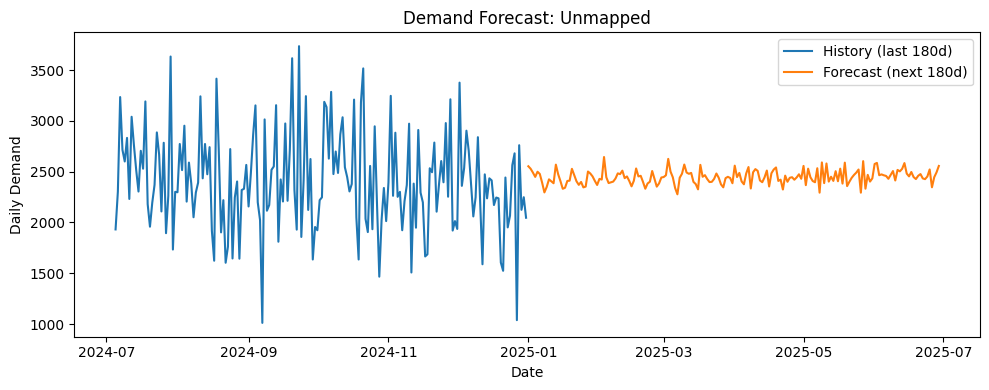

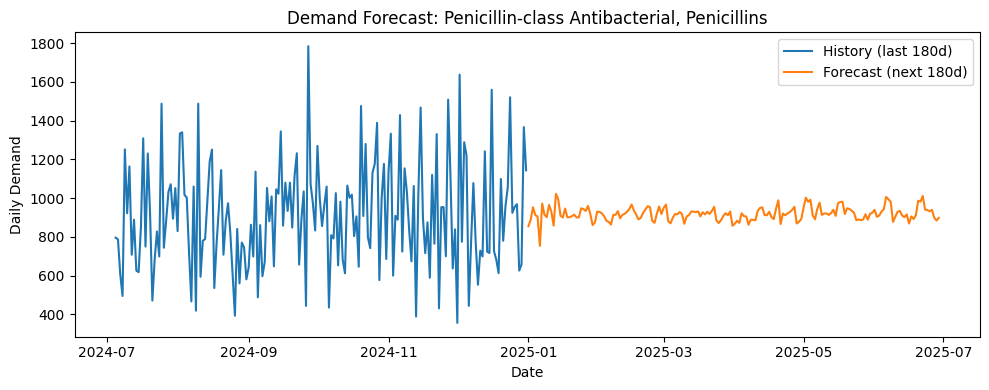

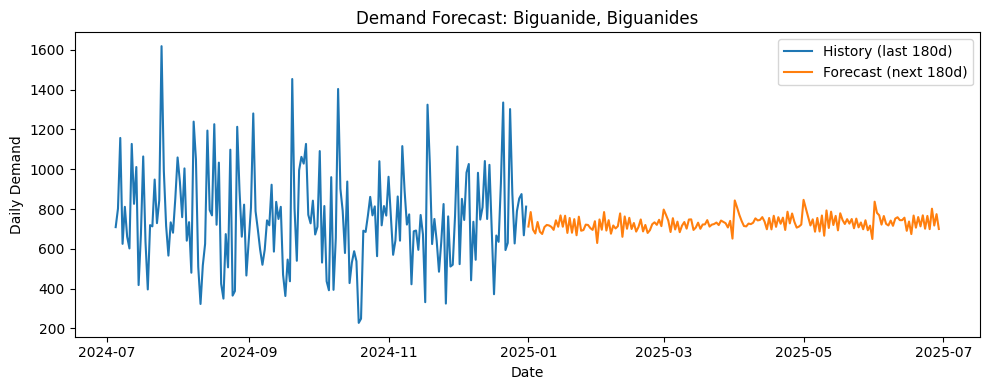

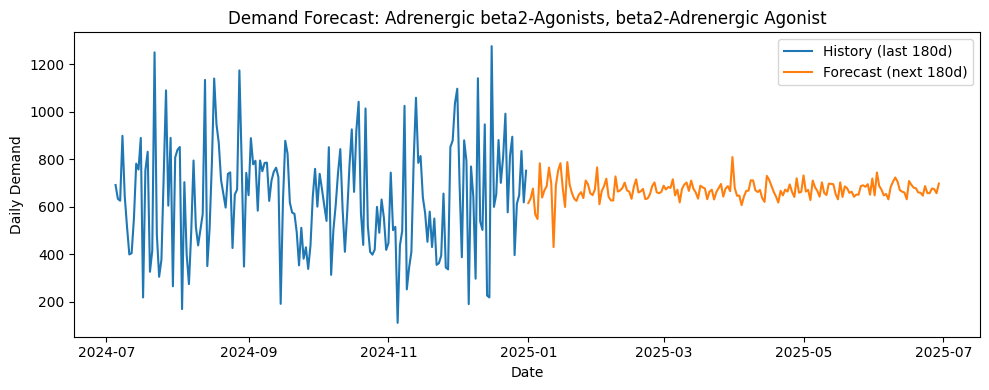

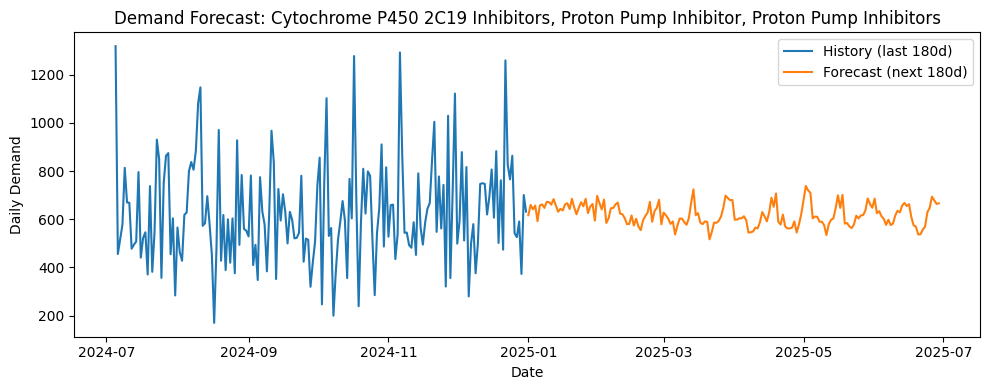

In [10]:
# --- 7) Quick sanity plots (top 5 classes) ---
top5 = metrics_df.sort_values("TotalDemand", ascending=False)["DrugClass"].head(5).tolist()

for cls in top5:
    sub_hist = daily_class[daily_class["DrugClass"] == cls].set_index("Date")["Demand"]
    sub_fcst = forecast_df[forecast_df["DrugClass"] == cls].set_index("Date")["ForecastDemand"]

    plt.figure(figsize=(10,4))
    plt.plot(sub_hist.tail(180), label="History (last 180d)")
    plt.plot(sub_fcst, label="Forecast (next 180d)")
    plt.title(f"Demand Forecast: {cls}")
    plt.xlabel("Date")
    plt.ylabel("Daily Demand")
    plt.legend()
    plt.tight_layout()
    plt.show()